In [1]:
import os
os.environ['TORCH_GEOMETRIC_BACKEND'] = 'pyg'

In [2]:
from sklearn.metrics import roc_auc_score

import torch
import torch.nn.functional as F
from torch import nn
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")

## 1. Ejemplo: Link Prediction con GNN en Dataset Cora

In [3]:
device = torch.device('cpu')

transform = T.Compose([
    T.NormalizeFeatures(),
    T.ToDevice(device),
    T.RandomLinkSplit(
      num_val=0.05,
      num_test=0.1,
      is_undirected=True,
      add_negative_train_samples=False),
])

dataset = Planetoid('../data/', name='Cora', transform=transform)

# After applying the `RandomLinkSplit` transform, the data is transformed from
# a data object to a list of tuples (train_data, val_data, test_data), with
# each element representing the corresponding split.
train_data, val_data, test_data = dataset[0]

In [4]:
class GCNLinkPredictor(nn.Module):
    def __init__(self, dim_in, dim_h, dim_z):
        super().__init__()
        torch.manual_seed(1234567)

        self.conv1 = GCNConv(dim_in, dim_h)
        self.conv2 = GCNConv(dim_h, dim_z)

        self.criterion = nn.BCEWithLogitsLoss()

    # Encoder
    def encode(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.conv2(h, edge_index)
        return h

    # Decoder (dot product)
    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

    def decode_all(self, z):
        adj = z @ z.t()
        return (adj > 0).nonzero(as_tuple=False).t()

    def fit(self, train_data, val_data, test_data, epochs, lr=0.01):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        best_val_auc = 0.0
        best_test_auc = 0.0

        for epoch in range(1, epochs + 1):
            loss = self._train_epoch(train_data, optimizer)
            val_auc = self.validate(val_data)
            test_auc = self.test(test_data)

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_test_auc = test_auc
                
                
            if epoch % 20 == 0:
              print(
                  f"Epoch {epoch:03d} | "
                  f"Loss: {loss:.4f} | "
                  f"Val AUC: {val_auc:.4f} | "
                  f"Test AUC: {test_auc:.4f}"
              )

        print(f"Final Test AUC: {best_test_auc:.4f}")

    def _train_epoch(self, data, optimizer):
        self.train()
        optimizer.zero_grad()

        z = self.encode(data.x, data.edge_index)

        neg_edge_index = negative_sampling(
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=data.edge_label_index.size(1),
            method="sparse"
        )

        edge_index = torch.cat(
            [data.edge_label_index, neg_edge_index],
            dim=-1
        )

        edge_label = torch.cat(
            [
                data.edge_label,
                data.edge_label.new_zeros(neg_edge_index.size(1))
            ],
            dim=0
        )

        logits = self.decode(z, edge_index).view(-1)
        loss = self.criterion(logits, edge_label)

        loss.backward()
        optimizer.step()

        return loss.item()

    @torch.no_grad()
    def validate(self, data):
        return self._eval_auc(data)

    @torch.no_grad()
    def test(self, data):
        return self._eval_auc(data)

    @torch.no_grad()
    def _eval_auc(self, data):
        self.eval()
        z = self.encode(data.x, data.edge_index)
        logits = self.decode(z, data.edge_label_index).view(-1)
        probs = logits.sigmoid()

        return roc_auc_score(
            data.edge_label.cpu().numpy(),
            probs.cpu().numpy()
        )

In [5]:
model = GCNLinkPredictor(
    dim_in=dataset.num_features,
    dim_h=128,
    dim_z=64
).to(device)

model.fit(
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    epochs=200,
    lr=0.001
)

Epoch 020 | Loss: 0.6742 | Val AUC: 0.6635 | Test AUC: 0.6887
Epoch 040 | Loss: 0.6571 | Val AUC: 0.6127 | Test AUC: 0.6718
Epoch 060 | Loss: 0.6164 | Val AUC: 0.6836 | Test AUC: 0.7435
Epoch 080 | Loss: 0.5687 | Val AUC: 0.7242 | Test AUC: 0.7569
Epoch 100 | Loss: 0.5520 | Val AUC: 0.7405 | Test AUC: 0.7705
Epoch 120 | Loss: 0.5342 | Val AUC: 0.7683 | Test AUC: 0.7956
Epoch 140 | Loss: 0.5113 | Val AUC: 0.8072 | Test AUC: 0.8280
Epoch 160 | Loss: 0.5030 | Val AUC: 0.8167 | Test AUC: 0.8385
Epoch 180 | Loss: 0.4959 | Val AUC: 0.8209 | Test AUC: 0.8437
Epoch 200 | Loss: 0.4867 | Val AUC: 0.8251 | Test AUC: 0.8467
Final Test AUC: 0.8467


In [6]:
z = model.encode(test_data.x, test_data.edge_index)
final_edge_index = model.decode_all(z)


In [7]:
print("z")
z

z


tensor([[-0.0677,  0.0142,  0.1031,  ..., -0.0522,  0.0223,  0.0727],
        [ 0.0466,  0.0283,  0.0922,  ...,  0.1363, -0.0859,  0.1000],
        [-0.0480,  0.1255,  0.2261,  ...,  0.0644, -0.0371,  0.2221],
        ...,
        [-0.0026,  0.0594,  0.0494,  ..., -0.0220, -0.0190,  0.0618],
        [-0.0219,  0.0628,  0.1846,  ...,  0.0653, -0.0404,  0.1485],
        [-0.0926,  0.1287,  0.2413,  ..., -0.0071,  0.0155,  0.2067]],
       grad_fn=<AddBackward0>)

## 2. Ejemplo: Link Prediction con GraphSage en Dataset Cora

Iniciando entrenamiento con CustomLinkPredictionLoader ...
Epoch: 001, Loss: 1.4227, Val Acc: 0.3340, Test Acc: 0.3170
Epoch: 002, Loss: 1.3923, Val Acc: 0.2920, Test Acc: 0.2820
Epoch: 003, Loss: 1.3658, Val Acc: 0.2260, Test Acc: 0.2270
Epoch: 004, Loss: 1.4430, Val Acc: 0.2820, Test Acc: 0.2770
Epoch: 005, Loss: 1.3590, Val Acc: 0.3540, Test Acc: 0.3340
Epoch: 006, Loss: 1.3618, Val Acc: 0.3480, Test Acc: 0.3330
Epoch: 007, Loss: 1.3702, Val Acc: 0.3460, Test Acc: 0.3170
Epoch: 008, Loss: 1.3749, Val Acc: 0.3320, Test Acc: 0.3170
Epoch: 009, Loss: 1.3693, Val Acc: 0.3360, Test Acc: 0.3130
Epoch: 010, Loss: 1.3662, Val Acc: 0.3500, Test Acc: 0.3240
Epoch: 011, Loss: 1.3593, Val Acc: 0.3480, Test Acc: 0.3320
Epoch: 012, Loss: 1.3451, Val Acc: 0.3460, Test Acc: 0.3430
Epoch: 013, Loss: 1.3349, Val Acc: 0.3520, Test Acc: 0.3460
Epoch: 014, Loss: 1.3288, Val Acc: 0.3700, Test Acc: 0.3560
Epoch: 015, Loss: 1.3319, Val Acc: 0.3880, Test Acc: 0.3720
Epoch: 016, Loss: 1.3162, Val Acc: 0.4000

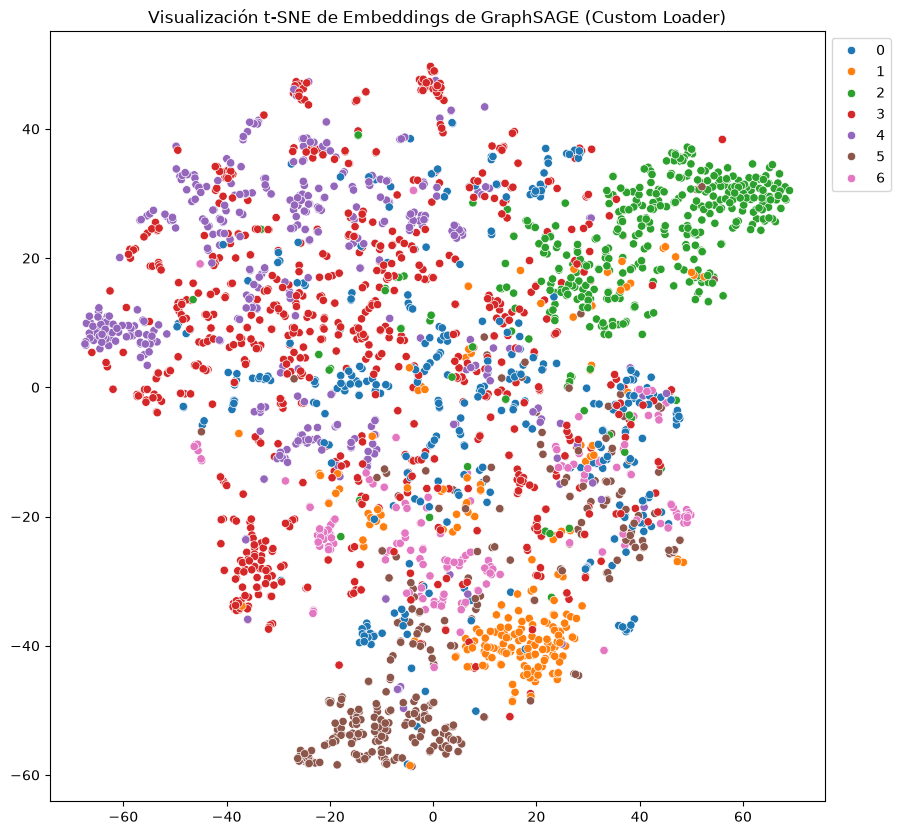

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración del Dataset y Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_name = 'Cora'
path = '../data'
dataset = Planetoid(path, dataset_name, transform=T.NormalizeFeatures())
data = dataset[0]

# 2. Tu Función de Random Walk (Intacta)
def random_walk_fast(edge_index, start, walk_length):
    row, col = edge_index
    num_nodes = int(max(row.max(), col.max()) + 1)

    neighbors = [[] for _ in range(num_nodes)]
    for r, c in zip(row, col):
        neighbors[int(r)].append(int(c))

    neighbors = [
        torch.tensor(n, dtype=torch.long) if len(n) > 0 else torch.tensor([-1])
        for n in neighbors
    ]

    walks = torch.zeros((len(start), walk_length), dtype=torch.long)
    walks[:, 0] = start

    for i in range(len(start)) :
        current = start[i].item()
        for t in range(1, walk_length):
            nbrs = neighbors[current]
            if nbrs.numel() == 1 and nbrs[0] == -1:
                next_node = current
            else:
                idx = torch.randint(len(nbrs), (1,)).item()
                next_node = nbrs[idx].item()

            walks[i, t] = next_node
            current = next_node

    return walks

# 3. Muestreador Custom en Python Puro (Sustituto total de NeighborLoader)
class CustomLinkPredictionLoader:
    def __init__(self, data, batch_size=256):
        self.data = data
        self.batch_size = batch_size
        
    def get_batch(self):
        # 1. Seleccionar nodos raíz aleatorios
        perm = torch.randperm(self.data.num_nodes)
        batch_nodos = perm[:self.batch_size]
        
        # 2. Obtener vecinos positivos vía Random Walk
        pos_nodos = random_walk_fast(self.data.edge_index, batch_nodos, walk_length=2)[:, 1]
        
        # 3. Obtener nodos negativos aleatorios
        neg_nodos = torch.randint(0, self.data.num_nodes, (batch_nodos.numel(),), dtype=torch.long)
        
        # 4. Concatenación tripartita (Tu lógica original)
        nodos_combinados = torch.cat([batch_nodos, pos_nodos, neg_nodos], dim=0)
        
        # 5. Extraer el subgrafo inducido por estos nodos de forma nativa en PyTorch:
        # Buscamos qué aristas del grafo original conectan a los nodos combinados
        nodos_unicos, inv_indices = torch.unique(nodos_combinados, return_inverse=True)
        
        # Máscara booleana para filtrar aristas en Python puro
        mask_row = torch.isin(self.data.edge_index[0], nodos_unicos)
        mask_col = torch.isin(self.data.edge_index[1], nodos_unicos)
        subgraph_mask = mask_row & mask_col
        
        sub_edge_index = self.data.edge_index[:, subgraph_mask]
        
        # Remapear los índices globales a índices locales de 0 a N-1 para la GNN
        node_idx_map = {node.item(): idx for idx, node in enumerate(nodos_unicos)}
        
        # Si el subgrafo se queda vacío de aristas por azar, usamos un fallback seguro
        if sub_edge_index.numel() > 0:
            sub_row = torch.tensor([node_idx_map[r.item()] for r in sub_edge_index[0]], dtype=torch.long)
            sub_col = torch.tensor([node_idx_map[c.item()] for c in sub_edge_index[1]], dtype=torch.long)
            local_edge_index = torch.stack([sub_row, sub_col], dim=0)
        else:
            local_edge_index = torch.empty((2, 0), dtype=torch.long)
            
        # El mapeo de características x para los nodos del subgrafo
        local_x = self.data.x[nodos_unicos]
        
        # Re-indexamos el lote tripartito original para saber su posición exacta dentro de `local_x`
        # 'inv_indices' nos da exactamente la posición de cada uno de los nodos_combinados dentro de nodos_unicos
        return local_x, local_edge_index, inv_indices

# Instanciamos nuestro cargador independiente
loader = CustomLinkPredictionLoader(data, batch_size=256)

# 4. Modelo GraphSAGE Estándar
class SAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers):
        super(SAGE, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            in_channels = in_channels if i == 0 else hidden_channels
            self.convs.append(SAGEConv(in_channels, hidden_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != self.num_layers - 1:
                x = x.relu()
                x = F.dropout(x, p=0.5, training=self.training)
        return x

model = SAGE(data.num_node_features, hidden_channels=32, num_layers=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
x_full, edge_index_full = data.x.to(device), data.edge_index.to(device)

# 5. Funciones de Entrenamiento y Evaluación
def train():
    model.train()
    optimizer.zero_grad()
    
    # Obtenemos los datos limpios en PyTorch puro
    local_x, local_edge_index, target_indices = loader.get_batch()
    
    local_x = local_x.to(device)
    local_edge_index = local_edge_index.to(device)
    
    # Pasar a la GNN
    out = model(local_x, local_edge_index)
    
    # Extraemos los embeddings de nuestros nodos tripartitos usando sus posiciones mapeadas
    out_inputs = out[target_indices]
    
    # Volvemos a dividir en 3 partes perfectas
    out_src, out_pos, out_neg = out_inputs.split(out_inputs.size(0) // 3, dim=0)
    
    # Pérdida idéntica a la tuya
    pos_loss = F.logsigmoid((out_src * out_pos).sum(-1)).mean()
    neg_loss = F.logsigmoid(-(out_src * out_neg).sum(-1)).mean()
    loss = -pos_loss - neg_loss
    
    loss.backward()
    optimizer.step()
    
    return float(loss)

@torch.no_grad()
def test():
    model.eval()
    out = model(x_full, edge_index_full).cpu()

    clf = LogisticRegression(max_iter=2000)
    clf.fit(out[data.train_mask], data.y[data.train_mask])

    val_acc = clf.score(out[data.val_mask], data.y[data.val_mask])
    test_acc = clf.score(out[data.test_mask], data.y[data.test_mask])

    return val_acc, test_acc, out

# 6. Ciclo de Entrenamiento
print("Iniciando entrenamiento con CustomLinkPredictionLoader ...")
for epoch in range(1, 51):
    loss = train()
    val_acc, test_acc, final_embeddings = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

# 7. t-SNE (Visualización)
print("\nGenerando gráfica t-SNE...")
palette = {}
for n, y in enumerate(set(data.y.numpy())):
    palette[y] = f'C{n}'

embd = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(final_embeddings.numpy())

plt.figure(figsize=(10, 10))
sns.scatterplot(x=embd[:, 0], y=embd[:, 1], hue=data.y.cpu().numpy(), palette=palette)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Visualización t-SNE de Embeddings de GraphSAGE (Custom Loader)")
plt.show()

In [11]:
embd_x = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(data.x.numpy())



<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

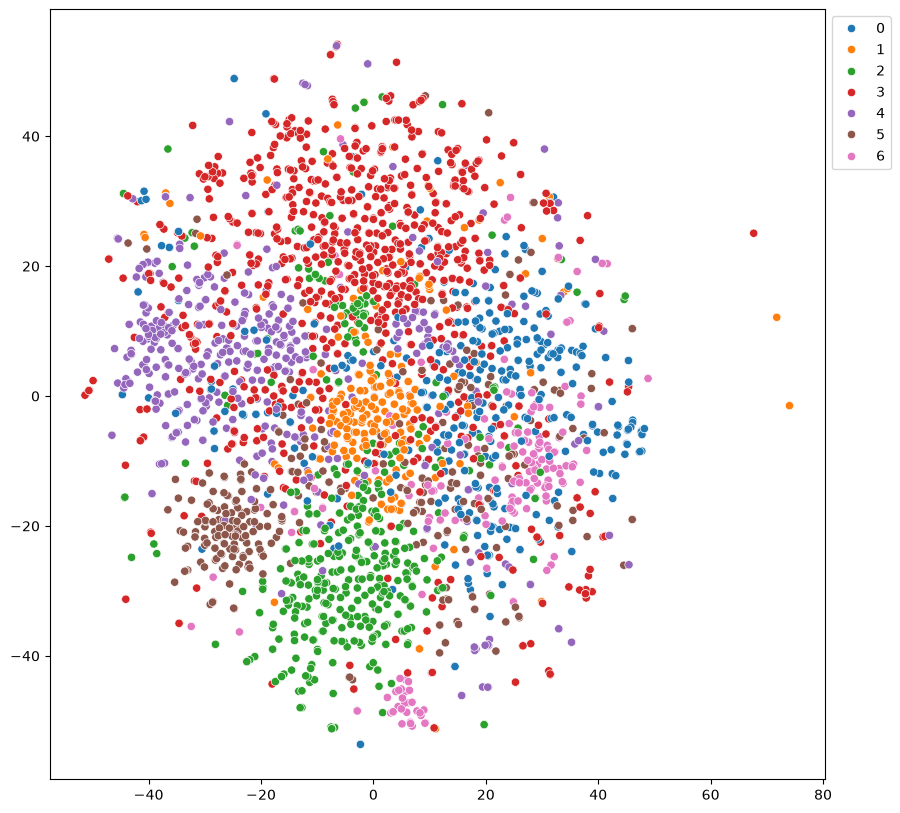

In [12]:
plt.figure(figsize=(10, 10))

sns.scatterplot(
    x=embd_x[:, 0],
    y=embd_x[:, 1],
    hue=data.y.cpu().numpy(),
    palette=palette
)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')